## Customer Churn Prediction Using Feature Engineering

### Project Overview:

Customer churn prediction is a classification problem focused on identifying customers who are likely to discontinue a telecommunications service.

This project evaluates the impact of **feature engineering, feature selection, model selection, and hyperparameter tuning** on churn prediction performance.

### Objectives

- Establish baseline performance using multiple classification models.
- Create informative features from existing customer data.
- Analyze feature importance and apply feature selection.
- Evaluate alternative classification models.
- Optimize promising models using hyperparameter tuning.
- Compare models using **Accuracy, Precision, Recall, and F1-score**.
- Focus on improving the **F1-score of the Churn class**.

### Workflow

**Data Loading → Data Cleaning → Baseline Model Comparison → Feature Engineering → Feature Set Selection → Feature Importance → Feature Selection → Hyperparameter Tuning → Final Evaluation → Findings**


### Step 1: Setup and Data Loading

In [192]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)


def get_prediction_scores(model, features):
    """Return positive-class scores for probability and margin-based models."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, 1]
    return model.decision_function(features)


# Set visualization style
sns.set_style("whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [157]:
# Load the dataset
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

df.head()

Dataset loaded successfully.
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


-----------------------------


### Step 2: Data Cleaning and Initial Preparation

In [158]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Data Quality Observation:**
 The `TotalCharges` column, which should be numerical, is currently an `object` type. This indicates there are non-numeric values in it. We need to fix this.

In [159]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values created during conversion
missing_total_charges = df["TotalCharges"].isnull().sum()
print(f"Missing TotalCharges values: {missing_total_charges}")

# Impute missing TotalCharges values with the median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Convert the target variable to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Remove rows with missing target values
df.dropna(subset=["Churn"], inplace=True)

# Remove customerID because it is an identifier rather than a predictive feature
df.drop("customerID", axis=1, inplace=True)

print("Data cleaning completed successfully.")

Missing TotalCharges values: 11
Data cleaning completed successfully.


In [160]:
# Display all columns
pd.set_option("display.max_columns", None)
display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [161]:
# Check the distribution of the target variable
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

------
### Step 3: Baseline Model

Multiple classification models are evaluated using the cleaned dataset without feature engineering. This establishes baseline performance and provides a reference for comparing the impact of feature engineering and feature selection.

In [162]:
# Install additional machine learning libraries
%pip install xgboost lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\bhavy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [163]:
# Import additional classification models
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [164]:
# Define baseline classification models
baseline_models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    
    "LightGBM": LGBMClassifier(
        random_state=42,
        verbosity=-1
    ),
    
    "Support Vector Machine": SVC(
        kernel="linear"
    )
}

In [165]:
# Define baseline features

X_base = df.drop("Churn", axis=1)
y_base = df["Churn"]

# Identify numerical and categorical features
numerical_features_base = X_base.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_base = X_base.select_dtypes(
    include=["object"]
).columns.tolist()

# Create preprocessing pipeline
preprocessor_base = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_base),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_base)
    ]
)

# Split the data
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base,
    y_base,
    test_size=0.2,
    random_state=42,
    stratify=y_base
)

print("Baseline data preparation completed successfully.")
print(f"Training data shape: {X_train_base.shape}")
print(f"Testing data shape: {X_test_base.shape}")

Baseline data preparation completed successfully.
Training data shape: (5634, 19)
Testing data shape: (1409, 19)


C:\Users\bhavy\AppData\Local\Temp\ipykernel_35760\1965452581.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_base = X_base.select_dtypes(


In [195]:
# Train and evaluate all baseline models

baseline_results = []
baseline_pipelines = {}

for model_name, classifier in baseline_models.items():

    # Create the complete preprocessing and model pipeline
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_base),
            ("classifier", classifier)
        ]
    )

    # Train the model
    model_pipeline.fit(X_train_base, y_train_base)

    # Generate predictions and positive-class scores
    y_pred = model_pipeline.predict(X_test_base)
    y_score = get_prediction_scores(model_pipeline, X_test_base)

    # Store the trained pipeline
    baseline_pipelines[model_name] = model_pipeline

    # Generate classification report
    report = classification_report(
        y_test_base,
        y_pred,
        output_dict=True
    )

    # Store metrics for the Churn class
    baseline_results.append({
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_test_base, y_score),
        "PR-AUC": average_precision_score(y_test_base, y_score)
    })

print("Baseline model evaluation completed successfully.")

Baseline model evaluation completed successfully.


In [196]:
# Create baseline model comparison table

baseline_results_df = pd.DataFrame(baseline_results)

# Sort models by Churn F1-Score
baseline_results_df = baseline_results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

# Round numerical values for clean presentation
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

baseline_results_df[metric_columns] = baseline_results_df[
    metric_columns
].round(3)

baseline_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.806,0.657,0.559,0.604,0.842,0.633
1,Gradient Boosting,0.806,0.674,0.524,0.589,0.843,0.664
2,LightGBM,0.798,0.639,0.545,0.589,0.834,0.632
3,XGBoost,0.784,0.605,0.537,0.569,0.820,0.622
4,Support Vector Machine,0.788,0.618,0.527,0.569,0.825,0.619
5,Random Forest,0.775,0.598,0.465,0.523,0.819,0.607


Baseline Findings:

Multiple classification models were evaluated using the cleaned dataset without feature engineering. Logistic Regression achieved the highest F1-score for the Churn class (0.604), while Logistic Regression and Gradient Boosting achieved the highest overall accuracy (0.806).

-----------------


### Step 4: Feature Engineering

New domain-based features are created from customer tenure, service usage, contract type, and billing information to improve the representation of churn-related patterns.

#### Step 4A: Compact Feature Engineering

A compact feature set is created using tenure grouping, service-related transformations, service usage counts, and the relationship between monthly charges and customer tenure.

In [168]:
# Create the compact engineered dataset
df_eng = df.copy()

# 1. Create tenure groups
bins = [0, 12, 24, 48, 60, 73]
labels = ["0-1 Year", "1-2 Years", "2-4 Years", "4-5 Years", "5+ Years"]

df_eng["tenure_group"] = pd.cut(
    df_eng["tenure"],
    bins=bins,
    labels=labels,
    right=False
)

# 2. Simplify service-related categories
df_eng["MultipleLines"] = df_eng["MultipleLines"].replace(
    {"No phone service": "No"}
)

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_columns:
    df_eng[col] = df_eng[col].replace(
        {"No internet service": "No"}
    )

# 3. Count the number of additional services
df_eng["num_add_services"] = (
    df_eng[service_columns] == "Yes"
).sum(axis=1)

# 4. Calculate monthly charges relative to tenure
df_eng["monthly_charge_ratio"] = (
    df_eng["MonthlyCharges"] /
    (df_eng["tenure"] + 1)
)

print("Compact feature engineering completed successfully.")
print(f"Original dataset shape: {df.shape}")
print(f"Compact engineered dataset shape: {df_eng.shape}")

df_eng.head()

Compact feature engineering completed successfully.
Original dataset shape: (7043, 20)
Compact engineered dataset shape: (7043, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_add_services,monthly_charge_ratio
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,1,14.925000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-4 Years,2,1.627143
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,2,17.950000
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4 Years,3,0.919565
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,0,23.566667


### Compact Feature Summary

The compact feature set introduces domain-relevant representations of customer tenure, service adoption, and billing behavior.

- `tenure_group`: Groups customers into meaningful tenure categories.
- `num_add_services`: Represents the number of additional services used.
- `monthly_charge_ratio`: Relates monthly charges to customer tenure.

Service-related categories are also simplified to reduce redundant categorical levels.

### Compact Feature Evaluation

The six classification models are evaluated using the compact engineered feature set. The same train-test split and evaluation metrics used for the baseline models are retained to ensure a fair comparison.

In [169]:
# Separate features and target
X_eng = df_eng.drop("Churn", axis=1)
y_eng = df_eng["Churn"]

# Identify numerical and categorical features
numerical_features_eng = X_eng.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_eng = X_eng.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Preprocessing pipeline
preprocessor_eng = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_eng
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_eng
        )
    ]
)

# Train-test split
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng,
    y_eng,
    test_size=0.2,
    random_state=42,
    stratify=y_eng
)

C:\Users\bhavy\AppData\Local\Temp\ipykernel_35760\1010828404.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_eng = X_eng.select_dtypes(


In [197]:
# Evaluate all models using compact engineered features
engineered_results = []
engineered_pipelines = {}

for model_name, classifier in baseline_models.items():

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_eng),
            ("classifier", classifier)
        ]
    )

    model_pipeline.fit(X_train_eng, y_train_eng)

    y_pred = model_pipeline.predict(X_test_eng)
    y_score = get_prediction_scores(model_pipeline, X_test_eng)

    engineered_pipelines[model_name] = model_pipeline

    report = classification_report(
        y_test_eng,
        y_pred,
        output_dict=True
    )

    engineered_results.append({
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_test_eng, y_score),
        "PR-AUC": average_precision_score(y_test_eng, y_score)
    })

engineered_results_df = pd.DataFrame(engineered_results)

engineered_results_df = engineered_results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

engineered_results_df[metric_columns] = engineered_results_df[
    metric_columns
].round(3)

engineered_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.803,0.664,0.519,0.583,0.846,0.663
1,Gradient Boosting,0.798,0.654,0.511,0.574,0.844,0.661
2,LightGBM,0.794,0.632,0.537,0.581,0.832,0.631
3,Support Vector Machine,0.789,0.647,0.447,0.528,0.823,0.635
4,Random Forest,0.786,0.621,0.500,0.554,0.822,0.618
5,XGBoost,0.784,0.606,0.527,0.564,0.821,0.620


### Compact Feature Findings

The compact feature-engineered models are compared with the baseline results to determine whether the newly created features improve predictive performance.

Accuracy is considered as the primary comparison metric, while the F1-score for the Churn class is also monitored to assess the model's ability to identify customers likely to churn.

#### Step 4B: Extended Feature Engineering

The feature set is further expanded by incorporating service adoption, customer relationship indicators, payment behavior, contract type, charge levels, and feature interactions.

In [193]:
# Create the extended engineered dataset
df_eng_v2 = df.copy()

# 1. Create tenure groups
bins = [0, 12, 24, 48, 60, 73]
labels = ["0-1 Year", "1-2 Years", "2-4 Years", "4-5 Years", "5+ Years"]

df_eng_v2["tenure_group"] = pd.cut(
    df_eng_v2["tenure"],
    bins=bins,
    labels=labels,
    right=False
)

# 2. Simplify service-related categories
df_eng_v2["MultipleLines"] = df_eng_v2["MultipleLines"].replace(
    {"No phone service": "No"}
)

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_columns:
    df_eng_v2[col] = df_eng_v2[col].replace(
        {"No internet service": "No"}
    )

# 3. Number of additional services
df_eng_v2["num_add_services"] = (
    df_eng_v2[service_columns] == "Yes"
).sum(axis=1)

# 4. Total number of services
df_eng_v2["total_services"] = (
    (df_eng_v2["PhoneService"] == "Yes").astype(int)
    + (df_eng_v2["MultipleLines"] == "Yes").astype(int)
    + df_eng_v2["num_add_services"]
)

# 5. Identify relatively new customers
df_eng_v2["is_new_customer"] = (
    df_eng_v2["tenure"] <= 12
).astype(int)

# 6. Identify customers with family relationships
df_eng_v2["has_family"] = (
    (df_eng_v2["Partner"] == "Yes") |
    (df_eng_v2["Dependents"] == "Yes")
).astype(int)

# 7. Identify electronic check users
df_eng_v2["uses_electronic_payment"] = (
    df_eng_v2["PaymentMethod"] == "Electronic check"
).astype(int)

# 8. Identify month-to-month contracts
df_eng_v2["is_month_to_month"] = (
    df_eng_v2["Contract"] == "Month-to-month"
).astype(int)

# 9. Identify long-term contracts
df_eng_v2["is_long_term_contract"] = (
    df_eng_v2["Contract"].isin(
        ["One year", "Two year"]
    )
).astype(int)

# 10. Calculate charge relative to tenure
df_eng_v2["charge_per_tenure_year"] = (
    df_eng_v2["MonthlyCharges"] /
    ((df_eng_v2["tenure"] / 12) + 1)
)

# 11. Interaction between services and tenure
df_eng_v2["service_tenure_interaction"] = (
    df_eng_v2["total_services"] *
    df_eng_v2["tenure"]
)

# 12. Combine contract and tenure group
df_eng_v2["contract_tenure_group"] = (
    df_eng_v2["Contract"].astype(str)
    + "_"
    + df_eng_v2["tenure_group"].astype(str)
)

print("Extended feature engineering completed successfully.")
print(f"Original dataset shape: {df.shape}")
print(f"Extended engineered dataset shape: {df_eng_v2.shape}")

df_eng_v2.head()

Extended feature engineering completed successfully.
Original dataset shape: (7043, 20)
Extended engineered dataset shape: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_add_services,total_services,is_new_customer,has_family,uses_electronic_payment,is_month_to_month,is_long_term_contract,charge_per_tenure_year,service_tenure_interaction,contract_tenure_group
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,1,1,1,1,1,1,0,27.553846,1,Month-to-month_0-1 Year
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-4 Years,2,3,0,0,0,0,1,14.856522,102,One year_2-4 Years
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,2,3,1,0,0,1,0,46.157143,6,Month-to-month_0-1 Year
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4 Years,3,3,0,0,0,0,1,8.905263,135,One year_2-4 Years
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,0,1,1,0,1,1,0,60.600000,2,Month-to-month_0-1 Year


### Extended Feature Summary

The extended feature set introduces additional representations of customer behavior and service relationships.

The features capture:

- Customer tenure and lifecycle stage
- Service adoption
- Customer family relationships
- Payment behavior
- Contract type
- Monthly charge levels
- Service-tenure interactions
- Contract-tenure combinations

These features are evaluated to determine whether the additional complexity provides measurable performance improvements over the compact feature set.

### Extended Feature Evaluation

The same six classification models are evaluated using the extended engineered feature set. The preprocessing strategy, train-test ratio, random state, and evaluation metrics are kept consistent with the previous experiments.

In [205]:
# Separate features and target
X_eng_v2 = df_eng_v2.drop("Churn", axis=1)
y_eng_v2 = df_eng_v2["Churn"]

# Train-test split before learning the charge threshold
X_train_eng_v2, X_test_eng_v2, y_train_eng_v2, y_test_eng_v2 = train_test_split(
    X_eng_v2,
    y_eng_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_eng_v2
)

# Learn the threshold from training data only
charge_threshold = X_train_eng_v2["MonthlyCharges"].median()

X_train_eng_v2 = X_train_eng_v2.copy()
X_test_eng_v2 = X_test_eng_v2.copy()

X_train_eng_v2["high_monthly_charge"] = (
    X_train_eng_v2["MonthlyCharges"] > charge_threshold
).astype(int)

X_test_eng_v2["high_monthly_charge"] = (
    X_test_eng_v2["MonthlyCharges"] > charge_threshold
).astype(int)

# Identify numerical and categorical features
numerical_features_eng_v2 = X_train_eng_v2.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_eng_v2 = X_train_eng_v2.select_dtypes(
    include=["str", "category"]
).columns.tolist()

# Preprocessing pipeline
preprocessor_eng_v2 = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_eng_v2
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_eng_v2
        )
    ]
)

In [198]:
# Evaluate all models using extended engineered features
engineered_v2_results = []
engineered_v2_pipelines = {}

for model_name, classifier in baseline_models.items():

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_eng_v2),
            ("classifier", classifier)
        ]
    )

    model_pipeline.fit(
        X_train_eng_v2,
        y_train_eng_v2
    )

    y_pred = model_pipeline.predict(
        X_test_eng_v2
    )
    y_score = get_prediction_scores(model_pipeline, X_test_eng_v2)

    engineered_v2_pipelines[model_name] = model_pipeline

    report = classification_report(
        y_test_eng_v2,
        y_pred,
        output_dict=True
    )

    engineered_v2_results.append({
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_test_eng_v2, y_score),
        "PR-AUC": average_precision_score(y_test_eng_v2, y_score)
    })

engineered_v2_results_df = pd.DataFrame(
    engineered_v2_results
)

engineered_v2_results_df = engineered_v2_results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

engineered_v2_results_df[metric_columns] = engineered_v2_results_df[
    metric_columns
].round(3)

engineered_v2_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Gradient Boosting,0.812,0.685,0.540,0.604,0.846,0.659
1,Logistic Regression,0.803,0.673,0.505,0.577,0.847,0.659
2,LightGBM,0.793,0.633,0.527,0.575,0.834,0.643
3,Support Vector Machine,0.793,0.667,0.439,0.529,0.826,0.641
4,XGBoost,0.791,0.627,0.527,0.573,0.826,0.625
5,Random Forest,0.789,0.628,0.497,0.555,0.822,0.611


#### Step 4C: Feature Set Comparison

The compact and extended feature sets are compared using the same classification models and evaluation metrics. The feature set providing the stronger overall performance is selected for subsequent feature importance analysis, feature selection, and hyperparameter tuning.

In [174]:
# Identify the best-performing model from each feature set
best_compact = engineered_results_df.iloc[0]
best_extended = engineered_v2_results_df.iloc[0]

feature_set_comparison = pd.DataFrame({
    "Feature Set": [
        "Compact",
        "Extended"
    ],
    "Best Model": [
        best_compact["Model"],
        best_extended["Model"]
    ],
    "Accuracy": [
        best_compact["Accuracy"],
        best_extended["Accuracy"]
    ],
    "Precision": [
        best_compact["Precision"],
        best_extended["Precision"]
    ],
    "Recall": [
        best_compact["Recall"],
        best_extended["Recall"]
    ],
    "F1-Score": [
        best_compact["F1-Score"],
        best_extended["F1-Score"]
    ]
})

feature_set_comparison

,Feature Set,Best Model,Accuracy,Precision,Recall,F1-Score
0,Compact,Logistic Regression,0.803,0.664,0.519,0.583
1,Extended,Gradient Boosting,0.812,0.685,0.540,0.604


### Feature Engineering Decision

The extended feature set achieved the strongest overall feature-engineering result. Gradient Boosting with the extended features achieved the highest accuracy of **0.812**, matched the best Churn F1-score of **0.604**, and achieved a ROC-AUC of **0.846**. The compact feature set achieved **0.803 accuracy** and a **0.583 Churn F1-score**.

Therefore, the **extended feature set is selected** for the remaining stages of the project, including feature importance analysis, feature selection, model comparison, and hyperparameter tuning.

----------
### Step 5: Feature Importance

Feature importance is analyzed using the selected extended feature set to identify the variables that contribute most to churn prediction. A Random Forest model is used to estimate the relative importance of the transformed features.

In [175]:
# Train Random Forest using the selected extended feature set
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_eng_v2),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_estimators=200
            )
        )
    ]
)

# Fit the pipeline
rf_pipeline.fit(
    X_train_eng_v2,
    y_train_eng_v2
)

# Extract transformed feature names
feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Extract Random Forest feature importance scores
importances = (
    rf_pipeline
    .named_steps["classifier"]
    .feature_importances_
)

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
).head(15)

# Display the top 15 features
feature_importance_df

,Feature,Importance
12,num__charge_per_tenure_year,0.141865
2,num__MonthlyCharges,0.092115
3,num__TotalCharges,0.088753
13,num__service_tenure_interaction,0.062142
1,num__tenure,0.061198
9,num__is_month_to_month,0.028786
39,cat__Contract_Month-to-month,0.027755
10,num__is_long_term_contract,0.023856
4,num__num_add_services,0.021378
46,cat__PaymentMethod_Electronic check,0.021172


### Feature Importance Visualization

The top 15 features are visualized according to their Random Forest importance scores. Higher importance values indicate a greater relative contribution to the model's predictions.

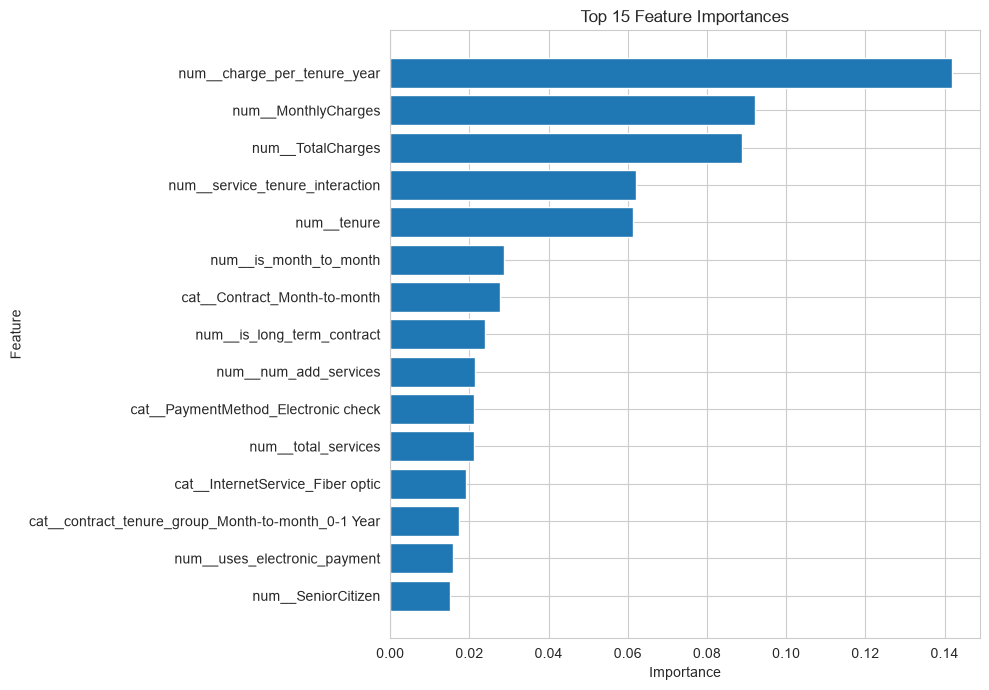

In [176]:
# Plot top 15 feature importances
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance_df["Feature"][::-1],
    feature_importance_df["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

### Feature Importance Findings

The feature importance analysis indicates that `charge_per_tenure_year`, `MonthlyCharges`, `TotalCharges`, `service_tenure_interaction`, and `tenure` are among the most influential features in the Random Forest model.


------
### Step 6: Feature Selection

Feature selection is performed to identify the most relevant features from the selected extended feature set. Three feature selection approaches are evaluated: Filter, Wrapper, and Embedded methods.

The selected features are then used to compare the performance of the six classification models.

### Feature Selection Methods

Three approaches are considered:

- **Filter Method:** Features are selected based on their statistical relationship with the target variable, independent of a machine learning model.
- **Wrapper Method:** Different feature subsets are evaluated using a predictive model to identify a useful subset of features.
- **Embedded Method:** Feature selection is incorporated into model training through model-based feature importance or regularization.

The three approaches are compared to determine which feature selection strategy provides the strongest predictive performance.

#### Step 6A: Filter Method

The Filter method selects features according to their statistical dependency with the target variable. Mutual Information is used to measure the relationship between each transformed feature and customer churn.

In [177]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Define the filter-based feature selector
filter_selector = SelectKBest(
    score_func=mutual_info_classif,
    k="all"
)

# Create pipeline with preprocessing and filter selection
filter_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_eng_v2),
        ("selector", filter_selector)
    ]
)

# Fit the selector using training data only
filter_pipeline.fit(
    X_train_eng_v2,
    y_train_eng_v2
)

# Extract feature scores
filter_feature_names = (
    filter_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

filter_scores = (
    filter_pipeline
    .named_steps["selector"]
    .scores_
)

filter_results_df = pd.DataFrame({
    "Feature": filter_feature_names,
    "Score": filter_scores
}).sort_values(
    by="Score",
    ascending=False
)

filter_results_df.head(15)

,Feature,Score
12,num__charge_per_tenure_year,0.133297
9,num__is_month_to_month,0.090589
39,cat__Contract_Month-to-month,0.087371
10,num__is_long_term_contract,0.084069
1,num__tenure,0.075400
53,cat__contract_tenure_group_Month-to-month_0-1 ...,0.064472
25,cat__InternetService_Fiber optic,0.055170
13,num__service_tenure_interaction,0.053040
8,num__uses_electronic_payment,0.052680
41,cat__Contract_Two year,0.052235


#### Step 6B: Wrapper Method

The Wrapper method evaluates feature subsets using a predictive model. Recursive Feature Elimination (RFE) with Logistic Regression is used to progressively remove less informative features and retain a selected subset.

In [178]:
from sklearn.feature_selection import RFE

# Define the estimator used by RFE
rfe_estimator = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Create RFE selector
wrapper_selector = RFE(
    estimator=rfe_estimator,
    n_features_to_select=20,
    step=1
)

# Create wrapper pipeline
wrapper_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_eng_v2),
        ("selector", wrapper_selector)
    ]
)

# Fit RFE using training data only
wrapper_pipeline.fit(
    X_train_eng_v2,
    y_train_eng_v2
)

# Extract transformed feature names
wrapper_feature_names = (
    wrapper_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Extract selected features
wrapper_support = (
    wrapper_pipeline
    .named_steps["selector"]
    .support_
)

wrapper_ranking = (
    wrapper_pipeline
    .named_steps["selector"]
    .ranking_
)

wrapper_results_df = pd.DataFrame({
    "Feature": wrapper_feature_names,
    "Selected": wrapper_support,
    "Ranking": wrapper_ranking
}).sort_values(
    by="Ranking"
)

wrapper_results_df.head(20)

,Feature,Selected,Ranking
1,num__tenure,True,1
2,num__MonthlyCharges,True,1
3,num__TotalCharges,True,1
10,num__is_long_term_contract,True,1
12,num__charge_per_tenure_year,True,1
26,cat__InternetService_No,True,1
25,cat__InternetService_Fiber optic,True,1
22,cat__MultipleLines_No,True,1
48,cat__tenure_group_0-1 Year,True,1
51,cat__tenure_group_4-5 Years,True,1


#### Step 6C: Embedded Method

The Embedded method performs feature selection during model training. L1-regularized Logistic Regression is used because the L1 penalty can reduce the coefficients of less informative features to zero.

In [179]:
from sklearn.feature_selection import SelectFromModel

# Define L1-regularized Logistic Regression
embedded_estimator = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    random_state=42,
    max_iter=1000
)

# Create embedded selector
embedded_selector = SelectFromModel(
    estimator=embedded_estimator,
    threshold="median"
)

# Create embedded feature selection pipeline
embedded_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_eng_v2),
        ("selector", embedded_selector)
    ]
)

# Fit the selector using training data only
embedded_pipeline.fit(
    X_train_eng_v2,
    y_train_eng_v2
)

# Extract transformed feature names
embedded_feature_names = (
    embedded_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Extract selected features
embedded_support = (
    embedded_pipeline
    .named_steps["selector"]
    .get_support()
)

embedded_results_df = pd.DataFrame({
    "Feature": embedded_feature_names,
    "Selected": embedded_support
})

embedded_results_df = embedded_results_df[
    embedded_results_df["Selected"]
]

embedded_results_df

C:\Users\bhavy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\bhavy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,Feature,Selected
0,num__SeniorCitizen,True
1,num__tenure,True
2,num__MonthlyCharges,True
3,num__TotalCharges,True
4,num__num_add_services,True
8,num__uses_electronic_payment,True
10,num__is_long_term_contract,True
12,num__charge_per_tenure_year,True
13,num__service_tenure_interaction,True
16,cat__Partner_No,True


In [180]:
# Count selected features from each method
filter_feature_count = len(filter_results_df)

wrapper_feature_count = (
    wrapper_pipeline
    .named_steps["selector"]
    .n_features_
)

embedded_feature_count = (
    embedded_pipeline
    .named_steps["selector"]
    .get_support()
    .sum()
)

feature_selection_summary = pd.DataFrame({
    "Method": [
        "Filter",
        "Wrapper",
        "Embedded"
    ],
    "Selected Features": [
        filter_feature_count,
        wrapper_feature_count,
        embedded_feature_count
    ]
})

feature_selection_summary

,Method,Selected Features
0,Filter,68
1,Wrapper,20
2,Embedded,34


### Feature Selection Summary

The transformed feature space contains 68 features. The Filter and Wrapper methods are evaluated using 20 selected features, while the Embedded method retains features based on the median coefficient threshold.

### Feature Selection Model Evaluation

Each feature selection method is evaluated using the same six classification models. The preprocessing and feature selection steps are included within the pipeline to ensure that feature selection is learned only from the training data.

Accuracy and Churn F1-score are used as the primary evaluation metrics.

In [181]:
# Define the filter selector with 20 selected features
filter_selector_20 = SelectKBest(
    score_func=mutual_info_classif,
    k=20
)

# Define all three feature selection methods
selection_methods = {
    "Filter": filter_selector_20,
    "Wrapper": RFE(
        estimator=LogisticRegression(
            random_state=42,
            max_iter=1000
        ),
        n_features_to_select=20,
        step=1
    ),
    "Embedded": SelectFromModel(
        estimator=LogisticRegression(
            penalty="l1",
            solver="liblinear",
            random_state=42,
            max_iter=1000
        ),
        threshold="median"
    )
}

In [199]:
# Evaluate all six models with each feature selection method
feature_selection_results = []

for selection_name, selector in selection_methods.items():

    for model_name, classifier in baseline_models.items():

        selection_model_pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor_eng_v2),
                ("selector", selector),
                ("classifier", classifier)
            ]
        )

        selection_model_pipeline.fit(
            X_train_eng_v2,
            y_train_eng_v2
        )

        y_pred = selection_model_pipeline.predict(
            X_test_eng_v2
        )
        y_score = get_prediction_scores(
            selection_model_pipeline,
            X_test_eng_v2
        )

        report = classification_report(
            y_test_eng_v2,
            y_pred,
            output_dict=True
        )

        feature_selection_results.append({
            "Selection Method": selection_name,
            "Model": model_name,
            "Accuracy": report["accuracy"],
            "Precision": report["1"]["precision"],
            "Recall": report["1"]["recall"],
            "F1-Score": report["1"]["f1-score"],
            "ROC-AUC": roc_auc_score(y_test_eng_v2, y_score),
            "PR-AUC": average_precision_score(y_test_eng_v2, y_score)
        })

feature_selection_results_df = pd.DataFrame(
    feature_selection_results
)

feature_selection_results_df = feature_selection_results_df.sort_values(
    by=["Accuracy", "F1-Score"],
    ascending=False
).reset_index(drop=True)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

feature_selection_results_df[metric_columns] = feature_selection_results_df[
    metric_columns
].round(3)

feature_selection_results_df

C:\Users\bhavy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\bhavy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\bhavy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\

,Selection Method,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Embedded,Gradient Boosting,0.806,0.670,0.527,0.590,0.845,0.659
1,Embedded,Logistic Regression,0.803,0.668,0.511,0.579,0.847,0.659
2,Filter,Gradient Boosting,0.802,0.655,0.537,0.590,0.842,0.651
3,Filter,LightGBM,0.794,0.635,0.527,0.576,0.834,0.641
4,Embedded,LightGBM,0.794,0.635,0.527,0.576,0.832,0.639
5,Wrapper,Gradient Boosting,0.793,0.641,0.497,0.560,0.843,0.649
6,Wrapper,Logistic Regression,0.793,0.647,0.481,0.552,0.844,0.650
7,Embedded,Support Vector Machine,0.791,0.661,0.439,0.527,0.827,0.643
8,Filter,Logistic Regression,0.791,0.645,0.471,0.544,0.839,0.640
9,Embedded,Random Forest,0.789,0.628,0.500,0.557,0.822,0.623


### Feature Selection Decision

The feature selection methods are compared based on model accuracy and the F1-score for the Churn class. The method and model combination providing the strongest overall performance is selected for the subsequent hyperparameter tuning stage.

In [183]:
# Identify the best result from feature selection
best_feature_selection = feature_selection_results_df.iloc[0]

print("Best feature selection configuration:")
print(f"Selection Method: {best_feature_selection['Selection Method']}")
print(f"Model: {best_feature_selection['Model']}")
print(f"Accuracy: {best_feature_selection['Accuracy']:.3f}")
print(f"Churn F1-Score: {best_feature_selection['F1-Score']:.3f}")

Best feature selection configuration:
Selection Method: Embedded
Model: Gradient Boosting
Accuracy: 0.806
Churn F1-Score: 0.590


#### Feature Selection Findings

The Filter, Wrapper, and Embedded feature selection methods were evaluated using the six classification models.

The **Embedded method with Gradient Boosting** achieved the strongest performance among the evaluated feature-selection configurations, with an accuracy of **0.806** and a Churn F1-score of **0.590**.

However, this performance was lower than the **Extended Feature Engineering + Gradient Boosting** result of **0.812 accuracy** and **0.604 Churn F1-score**. Therefore, the full extended feature set is retained for hyperparameter tuning.

-------
### Step 7: Hyperparameter Tuning

Hyperparameter tuning is performed on the best-performing model obtained after feature engineering. Grid Search with 5-fold cross-validation is used to identify an effective Gradient Boosting configuration.

In [200]:
from sklearn.model_selection import GridSearchCV

# Define Gradient Boosting pipeline using the selected extended feature set
tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_eng_v2),
        (
            "classifier",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

# Define hyperparameter grid
param_grid = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__learning_rate": [0.05, 0.1, 0.15],
    "classifier__max_depth": [2, 3, 4],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# Fit on training data
grid_search.fit(
    X_train_eng_v2,
    y_train_eng_v2
)

print("Hyperparameter tuning completed successfully.")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1-score: {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Hyperparameter tuning completed successfully.
Best parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 2, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best cross-validation F1-score: 0.586


### Hyperparameter Tuning Results

The Gradient Boosting model trained on the extended feature set is optimized using Grid Search and 5-fold cross-validation. The Churn F1-score is used as the optimization metric because correctly identifying customers likely to churn is a primary objective.

The best-performing hyperparameter configuration is selected for final evaluation on the unseen test set.

------
### Step 8: Final Model Evaluation

The best Gradient Boosting configuration identified through cross-validation is evaluated on the unseen test set. The final model is assessed using accuracy, precision, recall, Churn F1-score, ROC-AUC, and PR-AUC.

ROC-AUC measures ranking quality across classification thresholds, while PR-AUC is especially informative for the imbalanced churn target. A confusion matrix is also generated to examine the model's classification performance for churn and non-churn customers.

In [201]:
# Get the best tuned Gradient Boosting model
best_model = grid_search.best_estimator_

# Predict on the unseen test data
y_pred_final = best_model.predict(
    X_test_eng_v2
)
y_score_final = get_prediction_scores(
    best_model,
    X_test_eng_v2
)

# Generate classification report
final_report = classification_report(
    y_test_eng_v2,
    y_pred_final,
    output_dict=True
)

# Extract final metrics
final_accuracy = final_report["accuracy"]
final_precision = final_report["1"]["precision"]
final_recall = final_report["1"]["recall"]
final_f1 = final_report["1"]["f1-score"]
final_roc_auc = roc_auc_score(y_test_eng_v2, y_score_final)
final_pr_auc = average_precision_score(y_test_eng_v2, y_score_final)

print("Final Model Performance")
print("-----------------------")
print(f"Accuracy:        {final_accuracy:.3f}")
print(f"Precision:       {final_precision:.3f}")
print(f"Recall:          {final_recall:.3f}")
print(f"Churn F1-Score:  {final_f1:.3f}")
print(f"ROC-AUC:         {final_roc_auc:.3f}")
print(f"PR-AUC:          {final_pr_auc:.3f}")

Final Model Performance
-----------------------
Accuracy:        0.808
Precision:       0.678
Recall:          0.529
Churn F1-Score:  0.595
ROC-AUC:         0.846
PR-AUC:          0.666


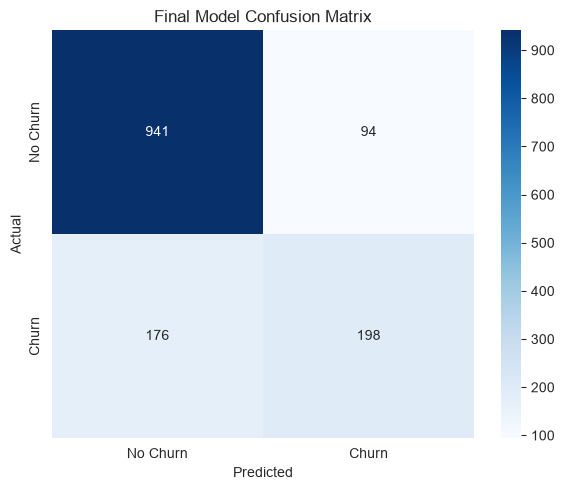

In [186]:
# Generate confusion matrix
cm = confusion_matrix(
    y_test_eng_v2,
    y_pred_final
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Model Confusion Matrix")
plt.tight_layout()
plt.show()

-------------
### Step 9: Final Comparison & Findings

The baseline, extended feature-engineered, feature-selected, and tuned models are compared to evaluate the overall impact of the modelling workflow.

Accuracy and Churn F1-score are emphasized to assess both overall predictive performance and the ability to identify customers likely to churn.

In [202]:
# Get best model from each stage
best_baseline = baseline_results_df.iloc[0]
best_engineered = engineered_v2_results_df.iloc[0]
best_selected = feature_selection_results_df.iloc[0]

# Create final comparison table
final_comparison_df = pd.DataFrame({
    "Stage": [
        "Baseline",
        "Extended Feature Engineering",
        "Feature Selection",
        "Final Tuned Model"
    ],
    "Model": [
        best_baseline["Model"],
        best_engineered["Model"],
        best_selected["Model"],
        "Gradient Boosting"
    ],
    "Accuracy": [
        best_baseline["Accuracy"],
        best_engineered["Accuracy"],
        best_selected["Accuracy"],
        final_accuracy
    ],
    "Precision": [
        best_baseline["Precision"],
        best_engineered["Precision"],
        best_selected["Precision"],
        final_precision
    ],
    "Recall": [
        best_baseline["Recall"],
        best_engineered["Recall"],
        best_selected["Recall"],
        final_recall
    ],
    "Churn F1-Score": [
        best_baseline["F1-Score"],
        best_engineered["F1-Score"],
        best_selected["F1-Score"],
        final_f1
    ],
    "ROC-AUC": [
        best_baseline["ROC-AUC"],
        best_engineered["ROC-AUC"],
        best_selected["ROC-AUC"],
        final_roc_auc
    ],
    "PR-AUC": [
        best_baseline["PR-AUC"],
        best_engineered["PR-AUC"],
        best_selected["PR-AUC"],
        final_pr_auc
    ]
})

final_metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "Churn F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

final_comparison_df[final_metric_columns] = final_comparison_df[
    final_metric_columns
].round(3)

final_comparison_df

,Stage,Model,Accuracy,Precision,Recall,Churn F1-Score,ROC-AUC,PR-AUC
0,Baseline,Logistic Regression,0.806,0.657,0.559,0.604,0.842,0.633
1,Extended Feature Engineering,Gradient Boosting,0.812,0.685,0.540,0.604,0.846,0.659
2,Feature Selection,Gradient Boosting,0.806,0.670,0.527,0.590,0.845,0.659
3,Final Tuned Model,Gradient Boosting,0.808,0.678,0.529,0.595,0.846,0.666


In [206]:
# Create a unified comparison table for all modelling stages

comparison_tables = []

# 1. Baseline
baseline_temp = baseline_results_df.copy()
baseline_temp["Stage"] = "Baseline"
baseline_temp["Feature Set"] = "Original Features"
baseline_temp["Tuned"] = "No"
comparison_tables.append(baseline_temp)

# 2. Compact Feature Engineering
compact_temp = engineered_results_df.copy()
compact_temp["Stage"] = "Feature Engineering"
compact_temp["Feature Set"] = "Compact"
compact_temp["Tuned"] = "No"
comparison_tables.append(compact_temp)

# 3. Extended Feature Engineering
extended_temp = engineered_v2_results_df.copy()
extended_temp["Stage"] = "Feature Engineering"
extended_temp["Feature Set"] = "Extended"
extended_temp["Tuned"] = "No"
comparison_tables.append(extended_temp)

# 4. Feature Selection
selection_temp = feature_selection_results_df.copy()
selection_temp["Stage"] = "Feature Selection"
selection_temp["Feature Set"] = selection_temp["Selection Method"]
selection_temp["Tuned"] = "No"

# Remove Selection Method after using it as feature-set information
selection_temp = selection_temp.drop(columns=["Selection Method"])

comparison_tables.append(selection_temp)

# 5. Hyperparameter Tuning
# Tuning was performed only for Gradient Boosting
tuned_row = pd.DataFrame([{
    "Model": "Gradient Boosting",
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1-Score": final_f1,
    "ROC-AUC": final_roc_auc,
    "PR-AUC": final_pr_auc,
    "Stage": "Hyperparameter Tuning",
    "Feature Set": "Extended",
    "Tuned": "Yes"
}])

comparison_tables.append(tuned_row)

# Combine all stages
master_comparison_df = pd.concat(
    comparison_tables,
    ignore_index=True
)

# Arrange columns
master_comparison_df = master_comparison_df[
    [
        "Stage",
        "Feature Set",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Tuned"
    ]
]

# Round metrics
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

master_comparison_df[metric_columns] = (
    master_comparison_df[metric_columns].round(3)
)

# Sort by stage and Churn F1-Score
master_comparison_df = master_comparison_df.sort_values(
    by=["Stage", "F1-Score"],
    ascending=[True, False]
).reset_index(drop=True)

master_comparison_df

,Stage,Feature Set,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Tuned
0,Baseline,Original Features,Logistic Regression,0.806,0.657,0.559,0.604,0.842,0.633,No
1,Baseline,Original Features,Gradient Boosting,0.806,0.674,0.524,0.589,0.843,0.664,No
2,Baseline,Original Features,LightGBM,0.798,0.639,0.545,0.589,0.834,0.632,No
3,Baseline,Original Features,XGBoost,0.784,0.605,0.537,0.569,0.820,0.622,No
4,Baseline,Original Features,Support Vector Machine,0.788,0.618,0.527,0.569,0.825,0.619,No
5,Baseline,Original Features,Random Forest,0.775,0.598,0.465,0.523,0.819,0.607,No
6,Feature Engineering,Extended,Gradient Boosting,0.812,0.685,0.540,0.604,0.846,0.659,No
7,Feature Engineering,Compact,Logistic Regression,0.803,0.664,0.519,0.583,0.846,0.663,No
8,Feature Engineering,Compact,LightGBM,0.794,0.632,0.537,0.581,0.832,0.631,No
9,Feature Engineering,Extended,Logistic Regression,0.803,0.673,0.505,0.577,0.847,0.659,No


----------
### Step 10: Final Conclusion

This project presented a systematic approach to customer churn prediction through data cleaning, leakage-aware feature engineering, feature selection, model comparison, and hyperparameter tuning.

Six classification models were evaluated throughout the modelling process: Logistic Regression, Random Forest, Gradient Boosting, XGBoost, LightGBM, and Support Vector Machine. The unified comparison table consolidates accuracy, precision, recall, Churn F1-score, ROC-AUC, and PR-AUC across the baseline, compact feature engineering, extended feature engineering, feature selection, and hyperparameter tuning stages.

The extended feature set produced the strongest overall feature-engineering result. Gradient Boosting with the extended features achieved the highest test accuracy of **81.2%**, matched the best Churn F1-score of **0.604**, achieved a ROC-AUC of **0.846**, and achieved a PR-AUC of **0.659**. This improved on the compact feature set's best result of **80.3% accuracy** and **0.583 Churn F1-score**.

Feature selection was evaluated using Filter, Wrapper, and Embedded methods. The best feature-selected configuration was the Embedded method with Gradient Boosting, which achieved **80.6% accuracy**, a **0.590 Churn F1-score**, a **0.845 ROC-AUC**, and a **0.659 PR-AUC**. Because this was lower in accuracy and F1-score than the extended feature-engineering result, the full extended feature set was retained.

Hyperparameter tuning was performed on Gradient Boosting using Grid Search with 5-fold cross-validation. The tuned model achieved **80.8% accuracy**, a **0.595 Churn F1-score**, a **0.846 ROC-AUC**, and a **0.666 PR-AUC** on the unseen test set. Tuning improved PR-AUC over the untuned extended model but did not improve accuracy or Churn F1-score.

Overall, the unified comparison confirms that feature engineering provided the strongest accuracy improvement in this project. The best overall approach for accuracy and Churn F1-score was **Gradient Boosting with the leakage-aware extended feature set**, achieving **81.2% test accuracy** and a **0.604 Churn F1-score**.

### Project Limitations and Next Steps

- The evaluation uses one stratified train-test split, so repeated cross-validation or testing on an external dataset would provide a stronger estimate of generalization.
- Churn is an imbalanced target, so future work should include Precision-Recall AUC, threshold optimization, and cost-sensitive evaluation.
- The project focuses on predictive performance and does not yet include deployment, monitoring, or an analysis of the business cost of missed churn predictions.
- A production version should package the preprocessing and model pipeline and expose it through a reproducible inference workflow.

### Key Takeaways

- **Best Approach:** Leakage-aware Extended Feature Engineering + Gradient Boosting
- **Best Test Accuracy:** 81.2%
- **Best Churn F1-Score:** 0.604, tied with baseline Logistic Regression
- **Best Extended-Model ROC-AUC:** 0.846
- **Best Tuned-Model PR-AUC:** 0.666
- **Models Evaluated:** Logistic Regression, Random Forest, Gradient Boosting, XGBoost, LightGBM, and Support Vector Machine
- **Feature Selection:** Compared Filter, Wrapper, and Embedded methods
- **Hyperparameter Tuning:** Grid Search with 5-fold cross-validation
- **Main Finding:** Feature engineering delivered the strongest accuracy improvement, while PR-AUC showed that tuning improved ranking quality for the imbalanced churn target.

The project demonstrates an end-to-end machine learning workflow for customer churn prediction, with emphasis on leakage-aware feature quality, systematic experimentation, and evaluation using both threshold-based and ranking-based metrics.